In [1]:
#vérifier le kernel: 

print("Ok")


Ok


In [3]:
url_basics =  "https://datasets.imdbws.com/title.basics.tsv.gz"   #création de la variable permettant de stocké le chemin d'accée

import pandas as pd

df_basics = pd.read_csv(
    url_basics,
    sep="\t",
)




In [4]:
df_basics.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short


In [ ]:
#Chez Datascope, je me concentre pour cette partie uniquement sur le filtre genre

In [5]:
df_basics.shape

(12246013, 9)

In [ ]:
#regarder le noms des colonnes

df_basics.columns

Index(['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult',
       'startYear', 'endYear', 'runtimeMinutes', 'genres'],
      dtype='str')

In [7]:
#voir les types 

df_basics.dtypes

tconst              str
titleType           str
primaryTitle        str
originalTitle       str
isAdult           int64
startYear           str
endYear             str
runtimeMinutes      str
genres              str
dtype: object

In [11]:
#je garde uniquement les colomne dont j'ai besoin pour le filtre genre:
    #tconst → identifiant unique IMDb (je suppose que ça sera ma clé pour construire notre Dataframe final)
    #originalTitle → le titre du film
    #genres → la base de ton filtre


#Ok on va d'abord faire un copie pour protéger l'original 

df_basics_copy=df_basics.copy()


df_basics_copy = df_basics.drop(columns=[  'startYear', 'endYear', 'runtimeMinutes', 'titleType', 'primaryTitle'])

df_basics_copy.head()

,tconst,originalTitle,isAdult,genres
0,tt0000001,Carmencita,0,"Documentary,Short"
1,tt0000002,Le clown et ses chiens,0,"Animation,Short"
2,tt0000003,Pauvre Pierrot,0,"Animation,Comedy,Romance"
3,tt0000004,Un bon bock,0,"Animation,Short"
4,tt0000005,Blacksmith Scene,0,Short


In [15]:
df_basics_copy.sample(20)

,tconst,originalTitle,isAdult,genres
2507425,tt12817582,Episode #1.476,0,Drama
8086326,tt33355464,Halloween,0,Comedy
7129,tt0007225,"Prudence, the Pirate",0,"Comedy,Drama"
6378399,tt26913296,Episode dated 28 March 2023,0,"News,Talk-Show"
10075218,tt5113902,Episode #3.3,0,Comedy
1630742,tt11196926,Episode #1.199,0,"Drama,Family"
387888,tt0404947,Estigarribia: Militar y presidente,0,"Documentary,Short"
7297633,tt3043622,Boy Next Door,0,"Music,Short"
8852224,tt36979782,Vindicating Grace,0,"Drama,Short"
6687740,tt27965972,Discharge,0,"Action,Adventure,Animation"


In [16]:
#Ok donc là dans genre j'ai à la fois le genre et le format donc je dois la slicer en deux colonne [Genre] et [format]
#Après vérification ci dessus. Short est bien un genre et non un format ici.
#donc on fait plutot un explode afin de dupliquer les films et qu'ils puissent réagir correctement aux filtres que l'on créera

df_genres = df_basics_copy.copy()   #je le copie pour pouvoir revenir en arriere

df_genres["genres"] = df_genres["genres"].str.split(",")
df_genres = df_genres.explode("genres")
df_genres["genres"] = df_genres["genres"].str.strip()

df_genres.sample(20)

,tconst,originalTitle,isAdult,genres
5446912,tt21326182,Episode #1.2143,0,Talk-Show
7955880,tt33035572,Sawyer vs Yukinojo! The Warcry Skyscraper Battle!,0,Animation
8259275,tt3428478,In the Club,0,Drama
8115541,tt33425058,Sheng si pai bao,0,Action
8643641,tt3600528,Training Camp with the Portsmouth Destroyers,0,Short
1050819,tt10151188,Today's Lunch,0,Short
3668647,tt14966584,Episode #1.14,0,Reality-TV
9236795,tt3864556,Episode #1.18,0,Talk-Show
4161748,tt15879862,Episode #1.3887,0,Game-Show
481367,tt0501521,Episode dated 9 December 1999,0,News


In [21]:
#Allez, un petit value_counts() pour voir tout les genres différents maintenant: 

df_genres['genres'].value_counts(dropna=False)  #Ok j'ai quand meme 528 NaN donc qui ne seront pas sensibles aux filtres. J'en fais quoi? Au vu du pourcentage que cela représente, je vais les droper.

df_genres = df_genres.dropna(subset=["genres"])

df_genres['genres'].value_counts(dropna=False)

genres
Drama          3428134
Comedy         2365037
Talk-Show      1517657
Short          1296160
News           1209803
Documentary    1163150
Romance        1137248
Family          895124
Reality-TV      686650
Animation       610245
\N              531574
Crime           516573
Action          511719
Adventure       470958
Game-Show       462967
Music           445092
Adult           399624
Sport           317189
Fantasy         274339
Mystery         262506
Horror          262309
Thriller        203472
History         183111
Biography       129444
Sci-Fi          125405
Musical          97761
War              42052
Western          31359
Film-Noir          878
Name: count, dtype: int64

In [ ]:
#Ok je vérifie les autres colonnes

df_genres.isna().sum().sort_values(ascending=False)  #Ok on va droper les 38

originalTitle    38
tconst            0
isAdult           0
genres            0
dtype: int64

In [ ]:
 #Ok on va droper les 38
df_genres = df_genres.dropna(subset=["originalTitle"])
df_genres.isna().sum().sort_values(ascending=False)

tconst           0
originalTitle    0
isAdult          0
genres           0
dtype: int64

In [24]:
df_genres.dtypes

tconst             str
originalTitle      str
isAdult          int64
genres             str
dtype: object

In [27]:
#Les genres presents sont :
genre_counts = df_genres["genres"].value_counts()
genre_counts

genres
Drama          3428130
Comedy         2365035
Talk-Show      1517652
Short          1296154
News           1209802
Documentary    1163146
Romance        1137247
Family          895124
Reality-TV      686649
Animation       610244
\N              531573
Crime           516573
Action          511718
Adventure       470958
Game-Show       462967
Music           445089
Adult           399624
Sport           317188
Fantasy         274339
Mystery         262505
Horror          262308
Thriller        203471
History         183109
Biography       129442
Sci-Fi          125405
Musical          97761
War              42052
Western          31359
Film-Noir          878
Name: count, dtype: int64

In [25]:
#je veux savoir le top genre

top_genres = df_genres["genres"].value_counts().head(10)
top_genres

genres
Drama          3428130
Comedy         2365035
Talk-Show      1517652
Short          1296154
News           1209802
Documentary    1163146
Romance        1137247
Family          895124
Reality-TV      686649
Animation       610244
Name: count, dtype: int64

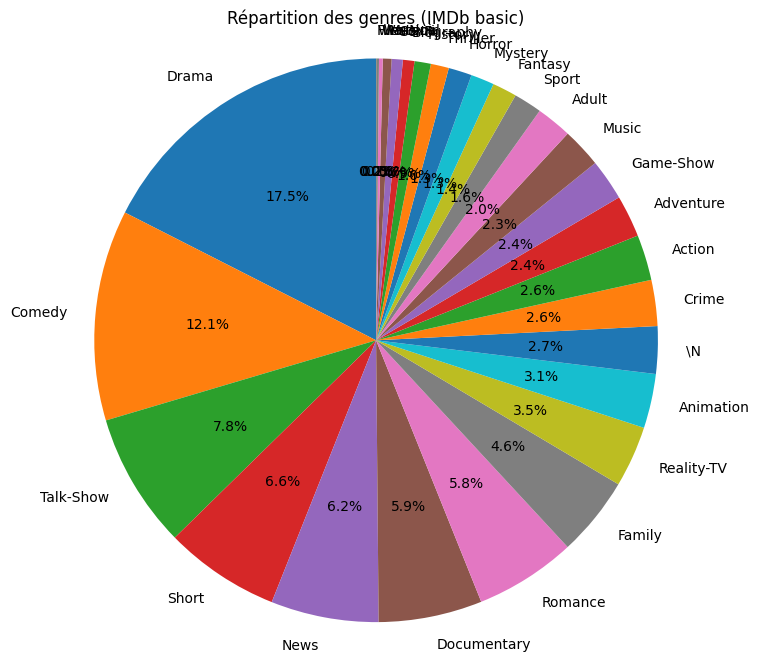

In [29]:
#Petit visuel voir ce que ça donne

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.pie(
    genre_counts,
    labels=genre_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des genres (IMDb basic)")
plt.axis("equal")  # pour un cercle bien rond
plt.show()

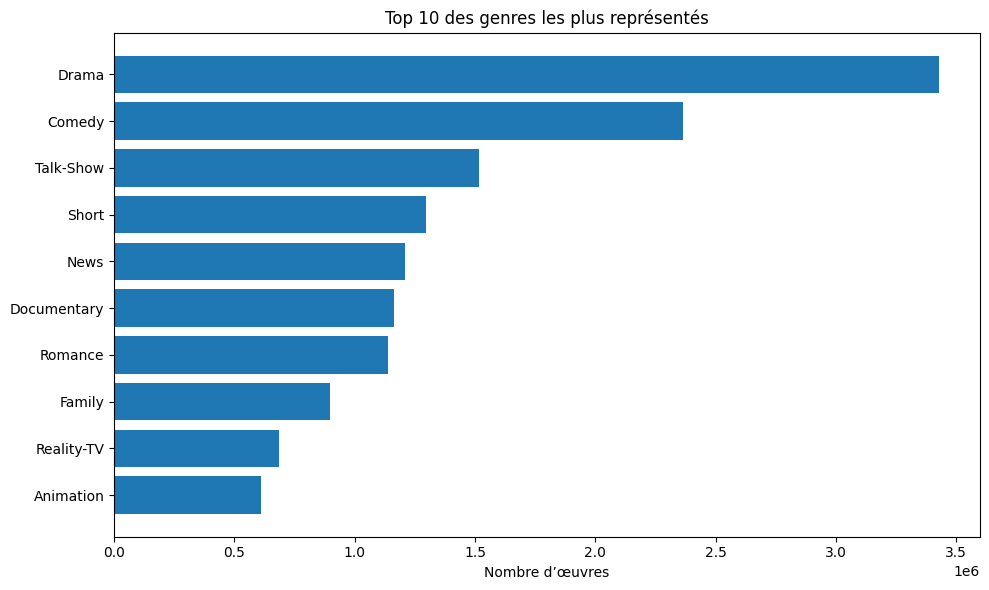

In [30]:
#Trop de catégories, plutot un bar chart horizontal du coup. Plus pertinent: 

plt.figure(figsize=(10, 6))
plt.barh(top_genres.index[::-1], top_genres.values[::-1])
plt.title("Top 10 des genres les plus représentés")
plt.xlabel("Nombre d’œuvres")
plt.tight_layout()
plt.show()
